<a href="https://colab.research.google.com/github/Ammara-Qaisar123/AI-ML-Internship-Tasks/blob/main/Task_3_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌸 AI/ML Internship – Task 3
Heart Disease Prediction
Name: Ammara Qaisar(DHC-994) Task: Heart Disease Prediction

**Objective:**

This project focuses on predicting the risk of heart disease using machine learning techniques.
We use the UCI Heart Disease dataset and apply classification models like Logistic Regression
and Random Forest to analyze patient health data and make predictions.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

## Dataset Loading

The dataset is loaded from the UCI Machine Learning Repository.
It contains various medical attributes such as age, cholesterol level,
blood pressure, and heart rate.

Missing values are handled during loading.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, names=columns, na_values='?')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Data Cleaning

Missing values are removed to ensure data quality.
The target variable is converted into binary format:
0 = No Disease
1 = Disease

In [3]:
print(df.isnull().sum())

df = df.dropna()

df['target'] = (df['target'] > 0).astype(int)

print("Cleaned Shape:", df.shape)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Cleaned Shape: (297, 14)


## Exploratory Data Analysis (EDA)

EDA helps in understanding relationships between variables.
A correlation heatmap is used to visualize feature relationships.

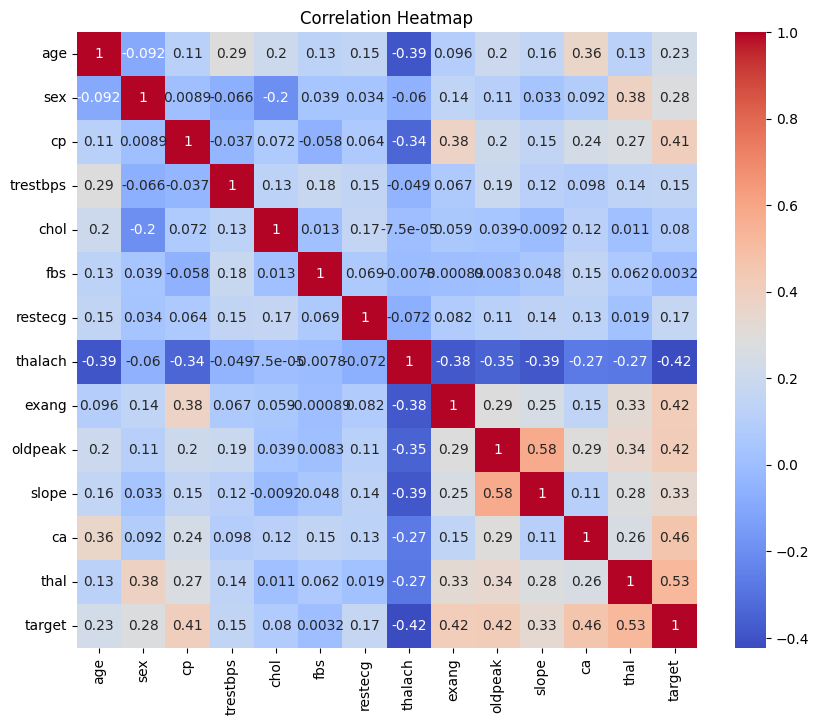

In [4]:
import os
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig("images/heatmap.png", dpi=300)
plt.show()

## Feature Visualization

We analyze important features like age and cholesterol
to observe patterns related to heart disease.

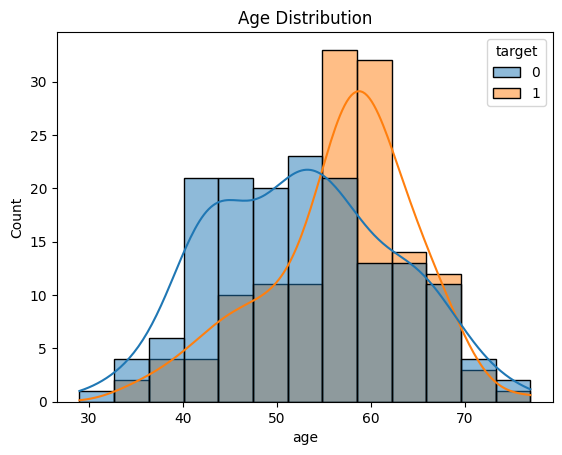

In [5]:
sns.histplot(data=df, x='age', hue='target', kde=True)
plt.title("Age Distribution")

plt.savefig("images/age_distribution.png", dpi=300)
plt.show()

## Feature Engineering

The dataset is split into training and testing sets.
Feature scaling is applied to normalize the data.

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

Two models are trained:
1. Logistic Regression
2. Random Forest

In [7]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

## Model Evaluation

Models are evaluated using accuracy and performance metrics.

In [8]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

LR Accuracy: 0.8666666666666667
RF Accuracy: 0.8666666666666667


## Confusion Matrix

This shows correct and incorrect predictions made by the model.

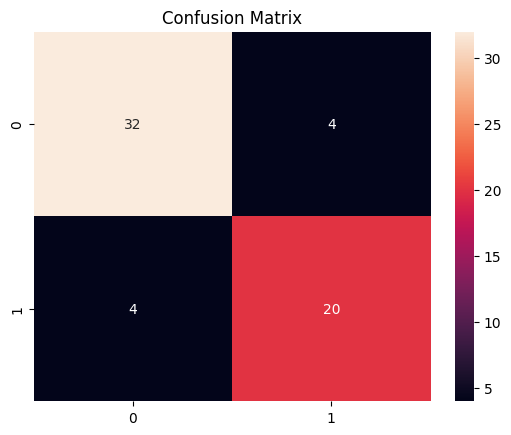

In [9]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300)
plt.show()

## ROC Curve

ROC curve helps compare model performance using AUC score.

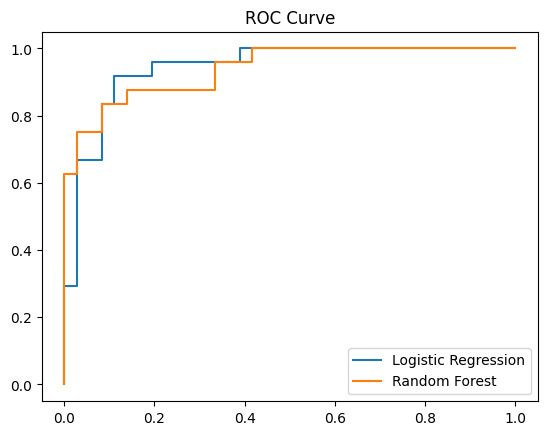

In [10]:
lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.legend()
plt.title("ROC Curve")

plt.savefig("images/roc_curve.png", dpi=300)
plt.show()

## Feature Importance

Random Forest helps identify the most important features.

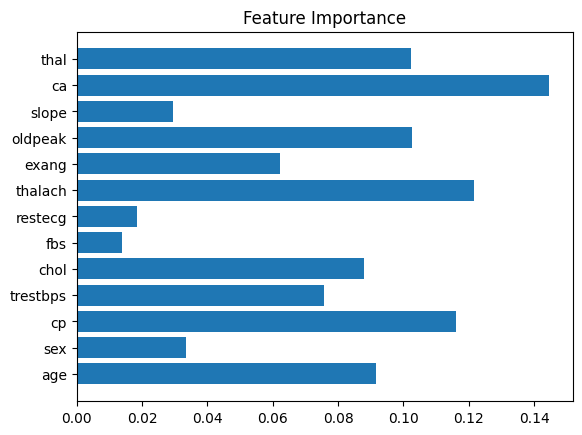

In [11]:
importance = rf.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")

plt.savefig("images/feature_importance.png", dpi=300)
plt.show()

## Conclusion

The project successfully predicts heart disease risk using machine learning.
Random Forest generally performs better due to its ability to capture complex patterns.

All visualizations are saved in the images folder and can be uploaded to GitHub.

In [12]:
!zip -r images.zip images

  adding: images/ (stored 0%)
  adding: images/feature_importance.png (deflated 29%)
  adding: images/roc_curve.png (deflated 30%)
  adding: images/age_distribution.png (deflated 9%)
  adding: images/confusion_matrix.png (deflated 34%)
  adding: images/heatmap.png (deflated 7%)


In [13]:
# Step 1: Zip the folder
!zip -r images.zip images

# Step 2: Download the zip file
from google.colab import files
files.download("images.zip")

updating: images/ (stored 0%)
updating: images/feature_importance.png (deflated 29%)
updating: images/roc_curve.png (deflated 30%)
updating: images/age_distribution.png (deflated 9%)
updating: images/confusion_matrix.png (deflated 34%)
updating: images/heatmap.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>